In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


Reading the file from CSV

In [3]:
df_main = pd.read_csv('../data/SGJobData.csv',low_memory=False)

Metadata

In [4]:
print("DataFrame shape:", df_main.shape)
print("DataFrame columns:", df_main.columns)   
print("DataFrame info:",df_main.dtypes)

DataFrame shape: (1048585, 22)
DataFrame columns: Index(['categories', 'employmentTypes', 'metadata_expiryDate',
       'metadata_isPostedOnBehalf', 'metadata_jobPostId',
       'metadata_newPostingDate', 'metadata_originalPostingDate',
       'metadata_repostCount', 'metadata_totalNumberJobApplication',
       'metadata_totalNumberOfView', 'minimumYearsExperience',
       'numberOfVacancies', 'occupationId', 'positionLevels',
       'postedCompany_name', 'salary_maximum', 'salary_minimum', 'salary_type',
       'status_id', 'status_jobStatus', 'title', 'average_salary'],
      dtype='str')
DataFrame info: categories                                str
employmentTypes                           str
metadata_expiryDate                       str
metadata_isPostedOnBehalf                bool
metadata_jobPostId                        str
metadata_newPostingDate                   str
metadata_originalPostingDate              str
metadata_repostCount                    int64
metadata_totalNumb

Describe Salary (min,max and average)

In [ ]:
print(f' {df_main['average_salary'].describe().round(2)}')
print(f' {df_main['salary_maximum'].describe().round(2)}')
print(f' {df_main['salary_minimum'].describe().round(2)}')


 count    654951.00
mean       4879.95
std        3235.98
min        1000.00
25%        3000.00
50%        4000.00
75%        5750.00
max       50000.00
Name: average_salary, dtype: float64
 count    654951.00
mean       5806.86
std        4293.49
min        1000.00
25%        3500.00
50%        4700.00
75%        7000.00
max      100000.00
Name: salary_maximum, dtype: float64
 count    654951.00
mean       3868.33
std        2074.23
min        1000.00
25%        2500.00
50%        3000.00
75%        4800.00
max       10000.00
Name: salary_minimum, dtype: float64
 originalPosting_Day
False    654951
Name: count, dtype: int64


Datetime  transformation

In [6]:
df_main['metadata_originalPostingDate'] = pd.to_datetime(df_main['metadata_originalPostingDate'])
df_main['metadata_newPostingDate']       = pd.to_datetime(df_main['metadata_newPostingDate'])
df_main['metadata_expiryDate']           = pd.to_datetime(df_main['metadata_expiryDate'])


Clipping avg,min and max salary

In [7]:
df_main['salary_maximum'] = df_main['salary_maximum'].clip(lower = 1000 , upper = 100000)
df_main['salary_minimum'] = df_main['salary_minimum'].clip(lower = 1000 , upper = 10000)
df_main['average_salary'] = df_main['average_salary'].clip(lower = 1000 , upper = 50000)

Month and Day Conversion of Posting Date

In [8]:
df_main['originalPosting_Month'] = df_main['metadata_originalPostingDate'].dt.to_period('M')
df_main['originalPosting_Day'] = df_main['metadata_originalPostingDate'].dt.day_name() 


Min,Max and Average Salary Range using CUT method

In [9]:
df_main["salary_range"] = pd.cut(df_main['average_salary'], bins=[0, 3000, 6000, 9000, 12000, np.inf], labels=['0-3k', '3k-6k', '6k-9k', '9k-12k', '12k+'])
df_main["max_salary_range"] = pd.cut(df_main['salary_maximum'], bins=[0, 3000, 6000, 9000, 12000, np.inf], labels=['0-3k', '3k-6k', '6k-9k', '9k-12k', '12k+'])
df_main["min_salary_range"] = pd.cut(df_main['salary_minimum'], bins=[0, 3000, 6000, 9000, 12000, np.inf], labels=['0-3k', '3k-6k', '6k-9k', '9k-12k', '12k+'])

Correlation Heatmap ; Notable observations are 
    1. Number of Views Vs Number of Applications 
    2. Average Salary Vs Years of Experience

    Positively Correleated

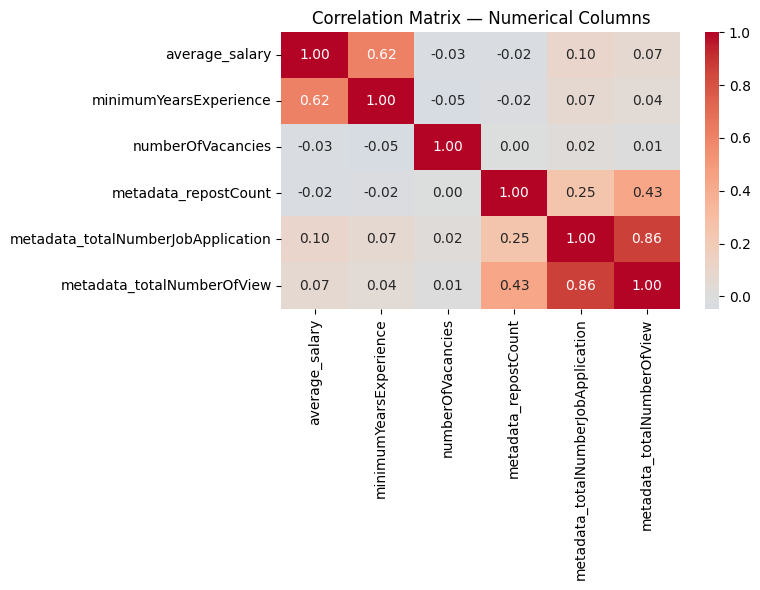

In [10]:
# Correlation heatmap:

num_cols = ['average_salary', 'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']
corr = df_main[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Columns')
plt.tight_layout()
plt.show()


Salary Distrubtuion (Salary Buckets) Vs Position Levels

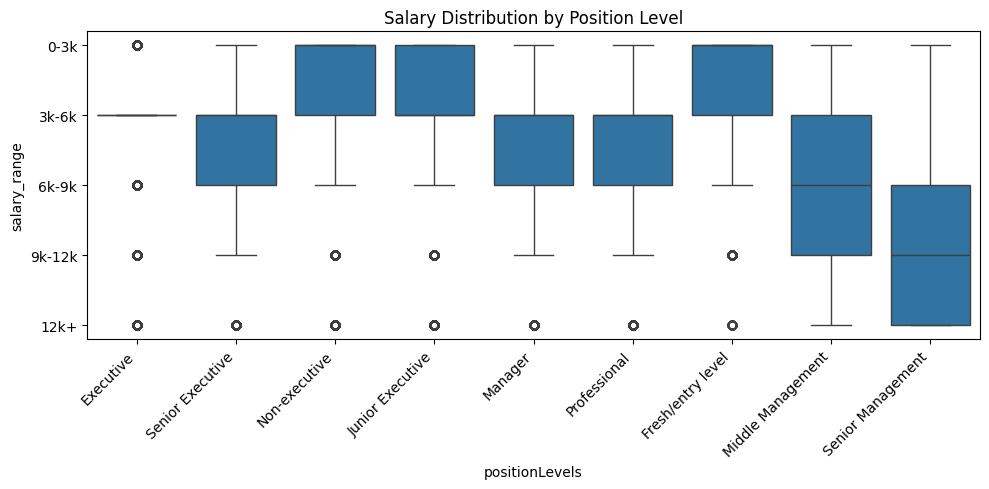

In [11]:
# Boxplot for outlier inspection:

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_main, x='positionLevels', y='salary_range')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Position Level')
plt.tight_layout()
plt.show()


PERSONA D Related Cleanup

In [12]:
df_main['title'].unique()

<ArrowStringArray>
[                                                  'Food Technologist - Clementi | Entry Level | Up to $2,800',
                                              'Software Engineer (Fab Support) (Java, CIM, Up to $ 5.5K) - DS',
                                                                                           'Senior Technician',
                                               'Senior .NET Developer (.NET Core, MVC, MVVC, SharePoint) - DS',
                                                                                    'Sales / Admin Cordinator',
                                                                                   'Software Support Engineer',
 'Urgent Hiring!!! Business Development Manager (Process Automation Solution, MES, Pre-sales, Siemens, Aveva)',
                                                             'IT Security Engineer (Maritime/ Cloud Security)',
                             'Assistant Sales Manager (Hunter Role)- Up to $5,500| Fr

In [13]:
df_main['positionLevels'].value_counts().sort_values(ascending=False)

positionLevels
Executive            253701
Junior Executive     167656
Non-executive        131608
Fresh/entry level    118661
Professional         112208
Manager              110122
Senior Executive     100459
Middle Management     27375
Senior Management     22807
Name: count, dtype: int64

Function to Split Categories and pick the Top Category from the List

In [14]:
import ast
def extract_first_category(cat_str):
  try:
    if pd.isna(cat_str):
          return "None"

    cat_list = ast.literal_eval(cat_str) if isinstance(cat_str, str) else cat_str
  
    if isinstance(cat_list, list) and len(cat_list) > 0 and isinstance(cat_list[0], dict):
      return cat_list[0].get('category', 'None').strip()

  except (ValueError, TypeError, SyntaxError):
    return "None"

   

Existing 'Categories' Column's Data transformed to category_list( string representation to actual list of dicts)

In [15]:
import ast

# Convert string representation to actual list of dicts
df_main['category_list'] = df_main['categories'].loc[df_main['categories'].notnull()].apply(lambda x: ast.literal_eval(x))


Category column crated from the list of dictionary from each row

In [16]:
df_main["category"] = df_main['category_list'].apply(extract_first_category).astype("str")

Dropping None Category records from the Dataframe 

In [17]:
df_main.drop(df_main[df_main['category'] == 'None'].index, inplace=True)

In [18]:
print(df_main["salary_maximum"].value_counts(ascending=False))
print(df_main["salary_minimum"].value_counts(ascending=False))
print(df_main["average_salary"].value_counts(ascending=False))


salary_maximum
5000     56147
3500     41486
4000     41041
4500     40729
6000     37167
         ...  
3590         1
4310         1
10992        1
10193        1
20835        1
Name: count, Length: 2018, dtype: int64
salary_minimum
3000    91427
2500    54464
4000    44593
3500    42134
2000    36645
        ...  
4454        1
3335        1
2853        1
1915        1
7820        1
Name: count, Length: 1163, dtype: int64
average_salary
4000.0     37912
4500.0     22232
3500.0     22103
3000.0     20383
3750.0     20088
           ...  
22900.0        1
3405.0         1
8549.5         1
9148.5         1
19312.5        1
Name: count, Length: 3163, dtype: int64


In [19]:
df_main[df_main["category"] == "Information Technology"][["title","positionLevels","average_salary"]].value_counts().sort_values(ascending=False)

title                                                positionLevels     average_salary
Web Developer & Full-Stack Coding Intern             Fresh/entry level  1100.0            443
IT Helpdesk Analyst (Tai Seng)                       Executive          3150.0            305
Service Delivery Engineer (Central)                  Executive          3150.0            280
Production Test Engineer (ATE Test Program, C++/VB)  Executive          6000.0            163
EUC Engineer L2                                      Executive          3150.0            121
                                                                                         ... 
AI Specialist                                        Professional       11000.0             1
Java Software Engineer | Backend                     Executive          6100.0              1
Systems Programmer (PostgreSQL) Bank l Contract      Professional       8500.0              1
Voice Engineer                                       Professional  

In [20]:
df_main.dtypes

categories                                       str
employmentTypes                                  str
metadata_expiryDate                   datetime64[us]
metadata_isPostedOnBehalf                       bool
metadata_jobPostId                               str
metadata_newPostingDate               datetime64[us]
metadata_originalPostingDate          datetime64[us]
metadata_repostCount                           int64
metadata_totalNumberJobApplication             int64
metadata_totalNumberOfView                     int64
minimumYearsExperience                         int64
numberOfVacancies                              int64
occupationId                                 float64
positionLevels                                   str
postedCompany_name                               str
salary_maximum                                 int64
salary_minimum                                 int64
salary_type                                      str
status_id                                     

Creating a new dataframe called df for PersonaD

In [21]:
df = df_main[["category","employmentTypes","average_salary",
              "metadata_totalNumberJobApplication",
              "minimumYearsExperience",
              "positionLevels",
              "salary_minimum", 
              "salary_maximum",
              "originalPosting_Month", 
              "originalPosting_Day",
              "metadata_totalNumberOfView",
              "numberOfVacancies",
              "salary_range",
              "max_salary_range",
              "min_salary_range",
              "title"]]
df['conversion_rate'] = (df['metadata_totalNumberJobApplication'] / df['metadata_totalNumberOfView']) * 100

In [22]:
df.to_csv("../data/SGJobData_Persona4.csv", index=False)

Question 1

In [23]:
import pandas as pd

month_analysis = df.groupby('originalPosting_Month')['metadata_totalNumberJobApplication'].sum().sort_values(ascending=False)

# 4. Group by Day to see total applications
day_analysis = df.groupby('originalPosting_Day')['metadata_totalNumberJobApplication'].sum().sort_values(ascending=False)

# Analysis using the existing string columns in your sample
day_rank = df.groupby('originalPosting_Day')['metadata_totalNumberJobApplication'].sum()
month_rank = df.groupby('originalPosting_Month')['metadata_totalNumberJobApplication'].sum()

print("Applications by Month:\n", month_analysis)
print("\nApplications by Day:\n", day_analysis)
print("Day Rank", day_rank)
print("\nMonth Rank:\n", month_rank)

Applications by Month:
 originalPosting_Month
2023-05    469422
2023-06    291307
2023-04    228331
2023-03    157243
2023-02     77284
2024-04     37502
2023-10     34939
2023-01     34086
2024-03     16971
2024-05     15322
2024-01     13918
2022-12     13855
2024-02     13477
2023-07     12541
2023-08     10877
2023-09      9927
2023-11      9824
2023-12      8452
2022-11      6420
2022-10      1652
Freq: M, Name: metadata_totalNumberJobApplication, dtype: int64

Applications by Day:
 originalPosting_Day
Tuesday      306925
Thursday     287870
Wednesday    280614
Friday       251125
Monday       246885
Saturday      51126
Sunday        38805
Name: metadata_totalNumberJobApplication, dtype: int64
Day Rank originalPosting_Day
Friday       251125
Monday       246885
Saturday      51126
Sunday        38805
Thursday     287870
Tuesday      306925
Wednesday    280614
Name: metadata_totalNumberJobApplication, dtype: int64

Month Rank:
 originalPosting_Month
2022-10      1652
2022-11      6

In [24]:
import pandas as pd

# 1. Group by Day of the Week
# We calculate both 'sum' (total volume) and 'mean' (performance per post)
day_analysis = df.groupby(['originalPosting_Day', 'category'])['metadata_totalNumberJobApplication'].agg(['sum', 'mean'])
day_analysis = day_analysis.rename(columns={'sum': 'Total_Apps', 'mean': 'Avg_Apps_Per_Post'})

# 2. Group by Month
month_analysis = df.groupby(['originalPosting_Month', 'category'])['metadata_totalNumberJobApplication'].agg(['sum', 'mean'])
month_analysis = month_analysis.rename(columns={'sum': 'Total_Apps', 'mean': 'Avg_Apps_Per_Post'})

# 3. Sort to find the "Winners"
print("--- Top Days for Applications ---")
print(day_analysis.sort_values(by='Total_Apps', ascending=False).sort_index(level=0, ascending=True))

print("\n--- Top Months for Applications ---")
print(month_analysis.sort_values(by='Total_Apps', ascending=False).sort_index(level=0, ascending=True))

--- Top Days for Applications ---
                                                      Total_Apps  \
originalPosting_Day category                                       
Friday              Accounting / Auditing / Taxation       20540   
                    Admin / Secretarial                    24022   
                    Advertising / Media                     1970   
                    Architecture / Interior Design          1005   
                    Banking and Finance                    22167   
...                                                          ...   
Wednesday           Security and Investigation               674   
                    Social Services                         3445   
                    Telecommunications                       506   
                    Travel / Tourism                         407   
                    Wholesale Trade                         2096   

                                                      Avg_Apps_Per_Post  
origina

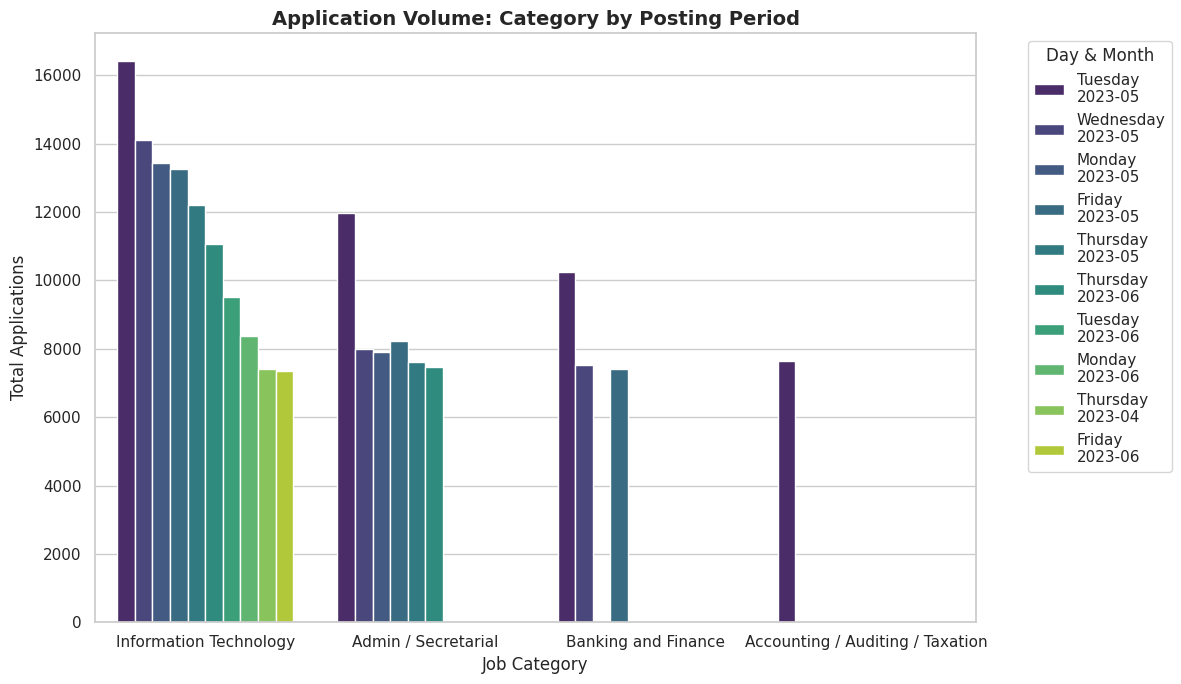

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert to Period type (YYYY-MM)
# This ensures 2023-10 comes after 2023-02 in your charts
# df['originalPosting_Month'] = pd.to_datetime(df['originalPosting_Month']).dt.to_period('M')

# 2. Combine Day and Month for the X-axis
# We convert back to string only for the purpose of the chart label
df['Time_Label'] = df['originalPosting_Day'] + "\n" + df['originalPosting_Month'].astype(str)

# 3. Aggregate for the chart
combined_data = df.groupby(['Time_Label', 'category'])['metadata_totalNumberJobApplication'].sum().reset_index()

# 4. Plotting
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=combined_data.sort_values(ascending=False, by='metadata_totalNumberJobApplication').head(20),
    x='category',
    y='metadata_totalNumberJobApplication',
    hue='Time_Label',
    palette='viridis'
)

plt.title('Application Volume: Category by Posting Period', fontsize=14, fontweight='bold')
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Total Applications', fontsize=12)
plt.legend(title='Day & Month', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

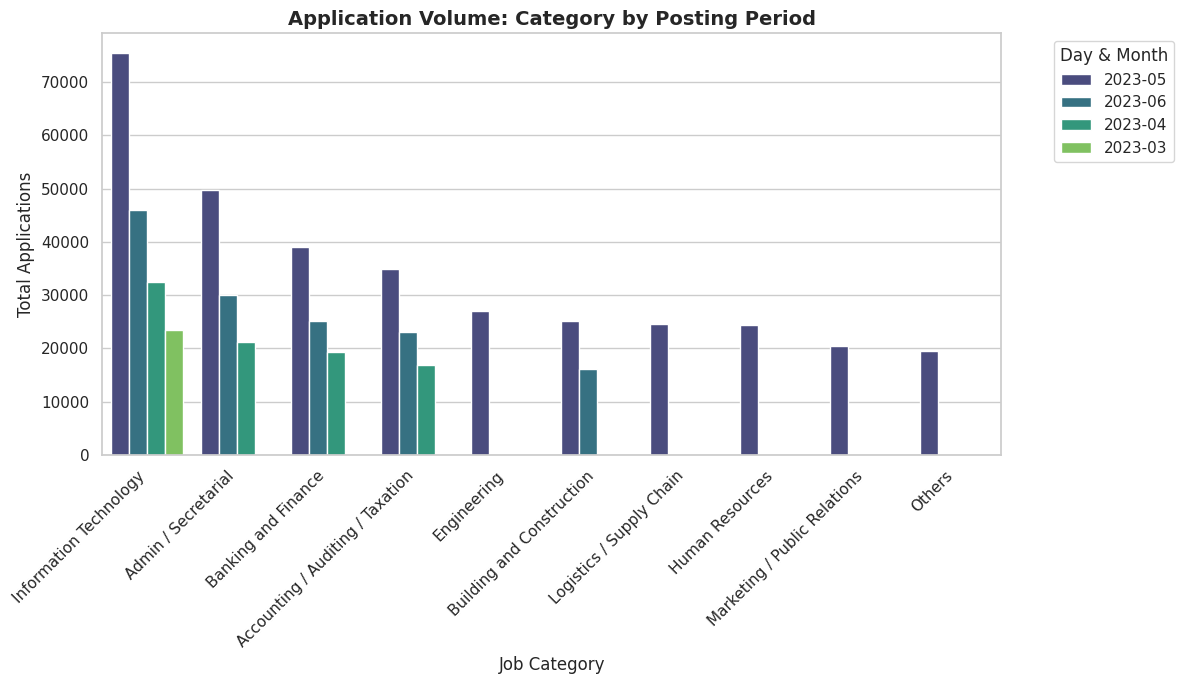

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert to Period type (YYYY-MM)
# This ensures 2023-10 comes after 2023-02 in your charts
# df['originalPosting_Month'] = pd.to_datetime(df['originalPosting_Month']).dt.to_period('M')

# 2. Combine Day and Month for the X-axis
# We convert back to string only for the purpose of the chart label
df['Time_Label'] =  df['originalPosting_Month'].astype(str)

# 3. Aggregate for the chart
combined_data = df.groupby(['Time_Label', 'category'])['metadata_totalNumberJobApplication'].sum().reset_index()

# 4. Plotting
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=combined_data.sort_values(ascending=False, by='metadata_totalNumberJobApplication').head(20),
    x='category',
    y='metadata_totalNumberJobApplication',
    hue='Time_Label',
    palette='viridis'
)
plt.xticks(rotation=45, ha='right')
plt.title('Application Volume: Category by Posting Period', fontsize=14, fontweight='bold')
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Total Applications', fontsize=12)
plt.legend(title='Day & Month', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

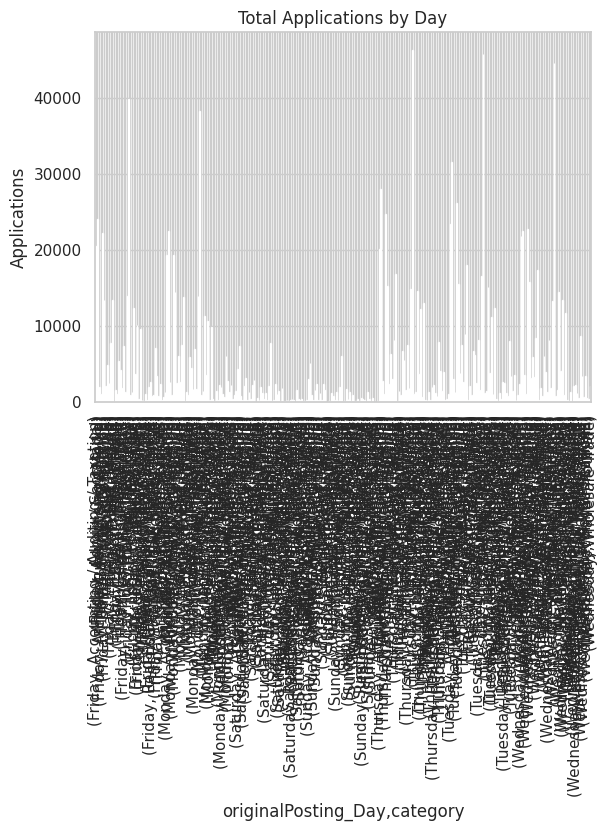

In [27]:
import matplotlib.pyplot as plt

# Plotting Top Days
day_analysis['Total_Apps'].plot(kind='bar', title='Total Applications by Day')
plt.ylabel('Applications')
plt.show()

Question 3

/tmp/ipykernel_5021/1282025831.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_df, y='category', x='Apps_Per_Vacancy', palette='flare')


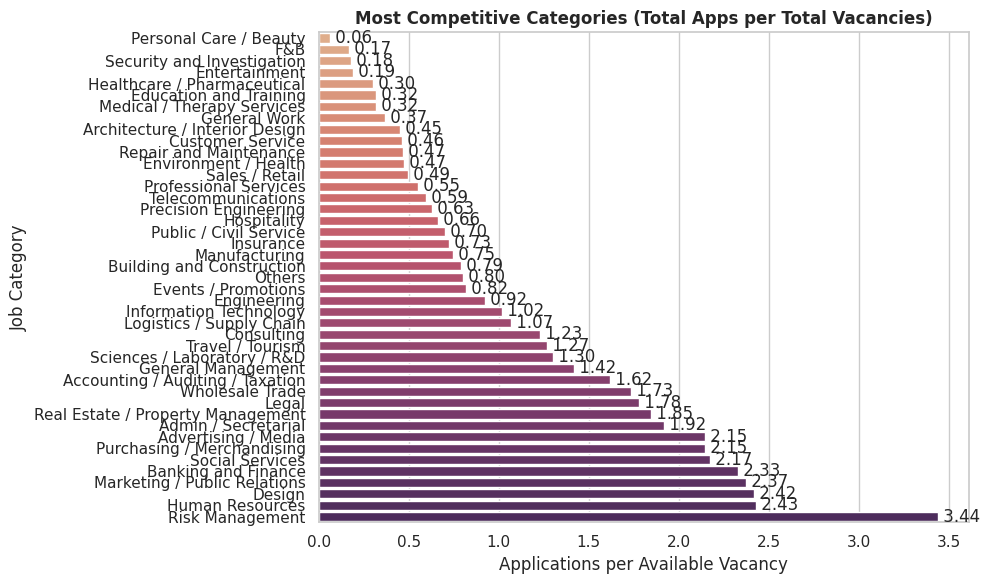

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate both Applications and Vacancies by Category
# We sum them up to get the total volume for each industry
agg_df = df.groupby(['category']).agg({
    'metadata_totalNumberJobApplication': 'sum',
    'numberOfVacancies': 'sum'
}).reset_index()

# 2. Calculate the Ratio: Total Apps / Total Vacancies
agg_df['Apps_Per_Vacancy'] = agg_df['metadata_totalNumberJobApplication'] / agg_df['numberOfVacancies']

# 3. Sort by ratio (Lowest = Least Competitive / Easiest to get)
agg_df = agg_df.sort_values(by='Apps_Per_Vacancy', ascending=True) # Show top 20 most competitive categories

# 4. Horizontal Bar Chart for readability
plt.figure(figsize=(10, 6))
sns.barplot(data=agg_df, y='category', x='Apps_Per_Vacancy', palette='flare')

plt.title('Most Competitive Categories (Total Apps per Total Vacancies)', fontweight='bold')
plt.xlabel('Applications per Available Vacancy')
plt.ylabel('Job Category')

# Add text labels for exact ratios
for index, value in enumerate(agg_df['Apps_Per_Vacancy']):
    plt.text(value, index, f' {value:.2f}', va='center')

plt.tight_layout()
plt.show()

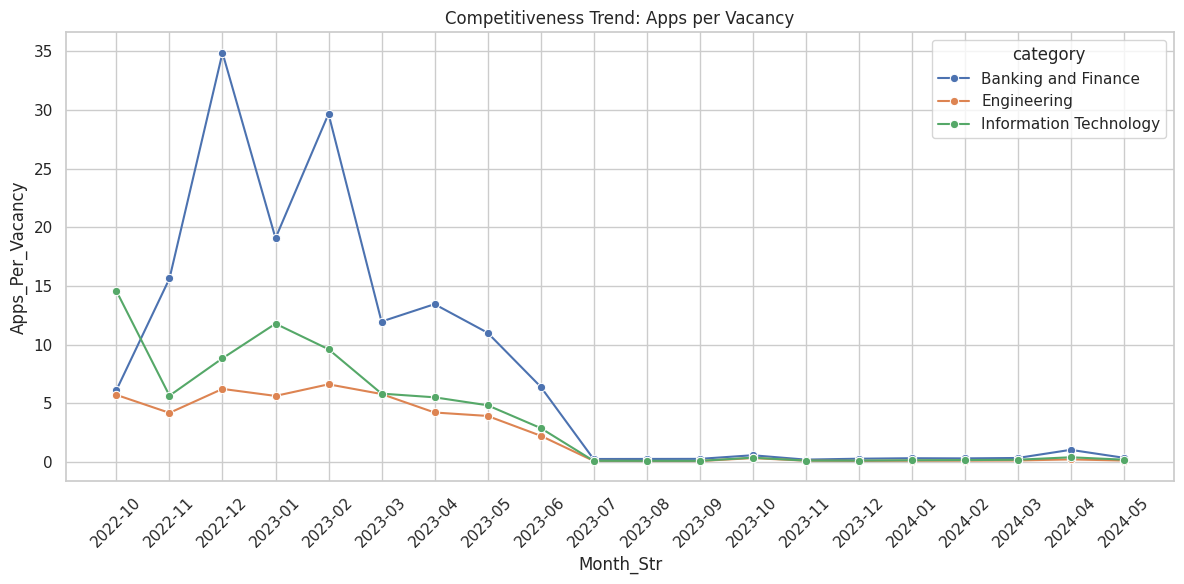

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Force numeric types for counts
# 'coerce' turns non-numbers into NaN, which we then fill with 0
df['metadata_totalNumberJobApplication'] = pd.to_numeric(df['metadata_totalNumberJobApplication'], errors='coerce').fillna(0)
df['numberOfVacancies'] = pd.to_numeric(df['numberOfVacancies'], errors='coerce').fillna(1)

# 2. Convert Month (Period) to String
# This is usually the culprit for "object type" errors in Seaborn lineplots
df['Month_Str'] = df['originalPosting_Month'].astype(str)

# 3. Aggregate
trend_df = df.groupby(['Month_Str', 'category']).agg({
    'metadata_totalNumberJobApplication': 'sum',
    'numberOfVacancies': 'sum'
}).reset_index()

# 4. Calculate Ratio
trend_df['Apps_Per_Vacancy'] = trend_df['metadata_totalNumberJobApplication'] / trend_df['numberOfVacancies']
trend_df = trend_df[(trend_df['category'] == "Information Technology") | (trend_df['category'] == "Engineering") | (trend_df['category'] == "Banking and Finance") | (trend_df['category'] == "Education")]
# 5. Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_df, x='Month_Str', y='Apps_Per_Vacancy', hue='category', marker='o')

plt.title('Competitiveness Trend: Apps per Vacancy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
primary_category =pd.DataFrame(df_main['category_list'].explode().dropna().tolist())
                                
primary_category.value_counts()

id  category                         
21  Information Technology               92869
11  Engineering                          49494
15  F&B                                  48461
1   Accounting / Auditing / Taxation     44720
6   Building and Construction            44374
2   Admin / Secretarial                  40187
35  Sales / Retail                       31339
24  Logistics / Supply Chain             31318
10  Education and Training               29987
5   Banking and Finance                  26661
41  Others                               24648
18  Healthcare / Pharmaceutical          23368
20  Human Resources                      20190
26  Marketing / Public Relations         18143
8   Customer Service                     17372
25  Manufacturing                        11750
36  Sciences / Laboratory / R&D           9931
17  General Work                          9252
28  Personal Care / Beauty                7941
16  General Management                    7139
4   Architecture / Int

In [31]:
df.head()

,category,employmentTypes,average_salary,metadata_totalNumberJobApplication,minimumYearsExperience,positionLevels,salary_minimum,salary_maximum,originalPosting_Month,originalPosting_Day,metadata_totalNumberOfView,numberOfVacancies,salary_range,max_salary_range,min_salary_range,title,conversion_rate,Time_Label,Month_Str
1,Information Technology,Permanent,4750.0,0,2,Executive,4000,5500,2023-04,Saturday,55,2,3k-6k,3k-6k,3k-6k,"Software Engineer (Fab Support) (Java, CIM, Up...",0.000000,2023-04,2023-04
2,Repair and Maintenance,Full Time,4200.0,7,3,Senior Executive,3800,4600,2023-04,Saturday,99,1,3k-6k,3k-6k,3k-6k,Senior Technician,7.070707,2023-04,2023-04
3,Information Technology,Permanent,7500.0,6,8,Senior Executive,5000,10000,2023-04,Saturday,113,1,6k-9k,9k-12k,3k-6k,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",5.309735,2023-04,2023-04
4,Admin / Secretarial,Full Time,2900.0,3,2,Non-executive,2400,3400,2023-04,Saturday,99,3,0-3k,3k-6k,0-3k,Sales / Admin Cordinator,3.030303,2023-04,2023-04
6,Information Technology,Permanent,9000.0,28,3,Manager,8000,10000,2023-04,Saturday,171,1,6k-9k,9k-12k,6k-9k,Urgent Hiring!!! Business Development Manager ...,16.374269,2023-04,2023-04


In [32]:
# from itertools import zip_longest

# # Create a 'zipped' column of tuples
# (x,y) =  [zip_longest(a, b) for a, b in zip(df_main['category_list'].astype(str), df_main['metadata_jobPostId'].astype(str))]

# x
# # Explode the zipped column
# df = df_main.explode('zipped')

# # Split the tuples back into separate columns
# df[['category_list', 'metadata_jobPostId']] = pd.DataFrame(df['zipped'].tolist(), index=df.index)
# df_main.drop(columns=['zipped'], inplace=True)
# df


In [33]:
df_main['metadata_originalPostingDate'].describe()

count                        654951
mean     2023-10-31 00:04:21.857757
min             2022-10-03 00:00:00
25%             2023-07-20 00:00:00
50%             2023-10-27 00:00:00
75%             2024-02-20 00:00:00
max             2024-05-29 00:00:00
Name: metadata_originalPostingDate, dtype: object

In [34]:
df_main['metadata_jobPostId'].describe()

count               654951
unique              654951
top       MCF-2023-0273977
freq                     1
Name: metadata_jobPostId, dtype: object

In [35]:
o = df_main['salary_maximum'].value_counts().sort_values(ascending=False) < 10
                      
o              
                   


salary_maximum
5000     False
3500     False
4000     False
4500     False
6000     False
         ...  
3590      True
4310      True
10992     True
10193     True
20835     True
Name: count, Length: 2018, dtype: bool

In [36]:
df_main.drop(df_main[df_main["salary_maximum"] >= 1000000].index, inplace=True)

In [37]:
np.min(df_main['salary_maximum']),np.max(df_main['salary_maximum']),df_main.count()

(np.int64(1000),
 np.int64(100000),
 categories                            654951
 employmentTypes                       654951
 metadata_expiryDate                   654951
 metadata_isPostedOnBehalf             654951
 metadata_jobPostId                    654951
 metadata_newPostingDate               654951
 metadata_originalPostingDate          654951
 metadata_repostCount                  654951
 metadata_totalNumberJobApplication    654951
 metadata_totalNumberOfView            654951
 minimumYearsExperience                654951
 numberOfVacancies                     654951
 occupationId                               0
 positionLevels                        654951
 postedCompany_name                    654951
 salary_maximum                        654951
 salary_minimum                        654951
 salary_type                           654951
 status_id                             654951
 status_jobStatus                      654951
 title                                 65495

In [38]:
average_salary_median   = df_main['average_salary'].median() 
average_salary_median

np.float64(4000.0)

In [39]:
df_missing_values_percentage = pd.DataFrame({'Null Counts': df_main.isnull().sum().sort_values(ascending=False).head(10),
                                                  'Null Percentage': (df_main.isnull().sum() / len(df_main) * 100).sort_values(ascending=False).head(10)})      

In [40]:
df_missing_values_percentage

,Null Counts,Null Percentage
occupationId,654951,100.0
employmentTypes,0,0.0
metadata_expiryDate,0,0.0
metadata_isPostedOnBehalf,0,0.0
categories,0,0.0
metadata_jobPostId,0,0.0
metadata_newPostingDate,0,0.0
metadata_repostCount,0,0.0
metadata_originalPostingDate,0,0.0
metadata_totalNumberJobApplication,0,0.0


<Axes: title={'center': 'Distribution of Minimum Years of Experience'}, xlabel='Minimum Years of Experience', ylabel='Frequency'>

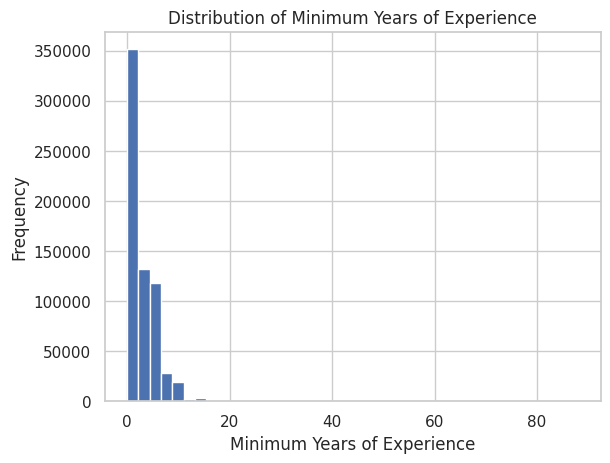

In [41]:
df_main['minimumYearsExperience'].plot(kind='hist', xlabel='Minimum Years of Experience', title='Distribution of Minimum Years of Experience',bins = 40)

In [42]:
correlation_matrix = ['average_salary', 'minimumYearsExperience', 'metadata_repostCount',  'metadata_totalNumberJobApplication']
correlation = df_main.select_dtypes(include=[np.number]).corr()[correlation_matrix]
correlation

,average_salary,minimumYearsExperience,metadata_repostCount,metadata_totalNumberJobApplication
metadata_repostCount,-0.030635,-0.029093,1.000000,0.264644
metadata_totalNumberJobApplication,0.088996,0.050798,0.264644,1.000000
metadata_totalNumberOfView,0.058164,0.022506,0.453284,0.873054
minimumYearsExperience,0.601498,1.000000,-0.029093,0.050798
numberOfVacancies,-0.031021,-0.049163,0.003827,-0.006321
occupationId,NaN,NaN,NaN,NaN
salary_maximum,0.977205,0.548273,-0.026373,0.084234
salary_minimum,0.909232,0.645343,-0.038131,0.085028
status_id,NaN,NaN,NaN,NaN
average_salary,1.000000,0.601498,-0.030635,0.088996


In [43]:
df_main.describe(include=np.datetime64)

,metadata_expiryDate,metadata_newPostingDate,metadata_originalPostingDate
count,654951,654951,654951
mean,2023-11-28 20:04:13.612865,2023-11-02 16:41:05.156630,2023-10-31 00:04:21.857757
min,2023-04-04 00:00:00,2023-03-28 00:00:00,2022-10-03 00:00:00
25%,2023-08-16 00:00:00,2023-07-21 00:00:00,2023-07-20 00:00:00
50%,2023-11-23 00:00:00,2023-10-27 00:00:00,2023-10-27 00:00:00
75%,2024-03-15 00:00:00,2024-02-20 00:00:00,2024-02-20 00:00:00
max,2024-06-28 00:00:00,2024-05-29 00:00:00,2024-05-29 00:00:00


In [44]:
dict_category = df_main['categories'].to_dict()
# df_category = pd.json_normalize()

In [45]:
c = len(dict_category)
c


654951

In [46]:
primary_category_dic = df_main["categories"].value_counts(normalize=True).sort_values(ascending=False).head(10)

In [47]:
df_category = pd.DataFrame(list(primary_category_dic.items()), columns=['Category', 'Proportion'] )
df_category

,Category,Proportion
0,"[{""id"":21,""category"":""Information Technology""}]",0.141795
1,"[{""id"":11,""category"":""Engineering""}]",0.075569
2,"[{""id"":15,""category"":""F&B""}]",0.073992
3,"[{""id"":1,""category"":""Accounting / Auditing / T...",0.068280
4,"[{""id"":6,""category"":""Building and Construction""}]",0.067752
5,"[{""id"":2,""category"":""Admin / Secretarial""}]",0.061359
6,"[{""id"":35,""category"":""Sales / Retail""}]",0.047849
7,"[{""id"":24,""category"":""Logistics / Supply Chain""}]",0.047817
8,"[{""id"":10,""category"":""Education and Training""}]",0.045785
9,"[{""id"":5,""category"":""Banking and Finance""}]",0.040707


In [48]:
skills = ['AI','Java', 'Python', 'Accounting', 'Sales', 'Digital Marketing', 'Engineering', 'Project Management', 'Data','AWS','Azure','Google Cloud','Artificial Intelligence','Machine Learning','Cloud','Cybersecurity','DevOps','UX','UI','Mobile','Frontend','Backend','Full Stack']
skill_counts = {skill: df['title'].str.contains(f' {skill} ', case=False).sum() for skill in skills}

In [49]:
skill_counts

{'AI': np.int64(370),
 'Java': np.int64(685),
 'Python': np.int64(150),
 'Accounting': np.int64(1249),
 'Sales': np.int64(14382),
 'Digital Marketing': np.int64(493),
 'Engineering': np.int64(2065),
 'Project Management': np.int64(297),
 'Data': np.int64(3467),
 'AWS': np.int64(1575),
 'Azure': np.int64(155),
 'Google Cloud': np.int64(158),
 'Artificial Intelligence': np.int64(41),
 'Machine Learning': np.int64(157),
 'Cloud': np.int64(1277),
 'Cybersecurity': np.int64(245),
 'DevOps': np.int64(492),
 'UX': np.int64(75),
 'UI': np.int64(102),
 'Mobile': np.int64(412),
 'Frontend': np.int64(139),
 'Backend': np.int64(431),
 'Full Stack': np.int64(548)}

In [50]:
ai = df[df['title'].str.contains(' AI ', case=False, regex=True)]['title'].str.lower().unique()
ai

<ArrowStringArray>
[                                   'research engineer/fellow (learn - ai chatbot) - ds4',
                                                                     'senior ai engineer',
                                       'scientist, centre for frontier ai research, ihpc',
                                                     'generative ai javascript developer',
 'postdoctoral fellow (the eric and wendy schmidt ai in science postdoctoral fellowship)',
                      'senior full-stack developer (srfsd) for ai singapore (technology)',
                                    'postdoctoral fellow at ai singapore (ai governance)',
                                                  'senior ai engineer（3d detection& bev）',
                                                'senior ai perception algorithm engineer',
                                    'senior ai engineer（segmentation & depth estimation）',
 ...
                                               'senior ai engineer

In [56]:
# Check how many jobs have 0 applications in each year
zeros_count = df[df['metadata_totalNumberJobApplication'] == 0].groupby('originalPosting_Month').size()
print("Number of jobs with 0 applications:", zeros_count)

Number of jobs with 0 applications: originalPosting_Month
2022-10       10
2022-11       11
2022-12      106
2023-01      197
2023-02      304
2023-03     2153
2023-04     3921
2023-05     8736
2023-06    13460
2023-07    40032
2023-08    40725
2023-09    37567
2023-10    35777
2023-11    35095
2023-12    29657
2024-01    36428
2024-02    29488
2024-03    32351
2024-04    32237
2024-05    30198
Freq: M, dtype: int64


In [57]:
df.dtypes

category                                    str
employmentTypes                             str
average_salary                          float64
metadata_totalNumberJobApplication        int64
minimumYearsExperience                    int64
positionLevels                              str
salary_minimum                            int64
salary_maximum                            int64
originalPosting_Month                 period[M]
originalPosting_Day                         str
metadata_totalNumberOfView                int64
numberOfVacancies                         int64
salary_range                           category
max_salary_range                       category
min_salary_range                       category
title                                       str
conversion_rate                         float64
Time_Label                                  str
Month_Str                                   str
dtype: object

In [65]:
skills = ['AI','Java', 'Python', 'Accounting', 'Digital Marketing', 'Data Engineering', 'Project Management', 'Data','AWS','Azure','Google Cloud','Artificial Intelligence','Machine Learning','Cloud','Cybersecurity','DevOps','UX','UI','Mobile','Frontend','Backend','Full Stack']
# Join your list into a single Regex pattern: "AI|Java|Python|Accounting..."
pattern = '|'.join(f' {skills} ')

def extract_skills(title):
    # Returns a list of skills found in the string
     for skill in skills :
         if ' '+skill.lower()+' ' in str(title).lower():
              return skill

df['skills_found'] = df['title'].apply(extract_skills)
df['skills_found'].value_counts(ascending=False)

skills_found
Data                       3389
AWS                        1566
Accounting                 1248
Cloud                      1038
Java                        684
Full Stack                  498
Digital Marketing           493
DevOps                      438
Mobile                      401
Backend                     388
AI                          370
Project Management          292
Cybersecurity               234
Machine Learning            146
Python                      140
Frontend                    138
Google Cloud                133
Azure                       115
UI                           95
UX                           75
Artificial Intelligence      36
Data Engineering             26
Name: count, dtype: int64